In [4]:
import pandas as pd
from IPython.display import display # used to display tables clearly.

df = pd.read_excel(r"C:\Users\Sai Lalit\Downloads\swiftship_delivery_delay_dataset.xlsx")
print("The Dataset loaded successfully.")

display(df.head())

The Dataset loaded successfully.


,Shipment_ID,Order_Date,Customer_Segment,Region,Product_Category,Shipping_Method,Shipping_Distance_km,Package_Weight_kg,Order_Value_CAD,Warehouse_Load_Level,Carrier_Rating,Weather_Risk,Previous_Delivery_Issues,Peak_Season,Promised_Delivery_Days,Delivery_Delayed
0,SHP-10001,2026-02-26,Small Business,Ontario,Home Goods,Economy,485,9.8,344.55,High,3.4,Low,0,No,7,0
1,SHP-10002,2026-04-07,Small Business,British Columbia,Apparel,Express,351,10.5,543.41,Low,4.0,Low,2,No,2,1
2,SHP-10003,2026-02-23,E-commerce Seller,British Columbia,Office Supplies,Economy,713,11.1,448.06,High,2.5,High,0,No,6,1
3,SHP-10004,2026-03-10,Enterprise,Ontario,Office Supplies,Express,531,12.2,659.53,Medium,4.0,Medium,2,Yes,1,1
4,SHP-10005,2026-05-11,E-commerce Seller,Atlantic,Apparel,Express,33,14.8,200.73,Medium,4.2,Medium,0,No,2,0


In [5]:
display(df.tail())

,Shipment_ID,Order_Date,Customer_Segment,Region,Product_Category,Shipping_Method,Shipping_Distance_km,Package_Weight_kg,Order_Value_CAD,Warehouse_Load_Level,Carrier_Rating,Weather_Risk,Previous_Delivery_Issues,Peak_Season,Promised_Delivery_Days,Delivery_Delayed
350,SHP-10013,2026-02-25,Retail Chain,Quebec,Electronics,Economy,639,8.1,689.72,Medium,3.7,Medium,2,Yes,6,0
351,SHP-10079,2026-03-11,Retail Chain,Alberta,Apparel,Express,458,5.4,359.99,High,4.9,Medium,0,Yes,2,0
352,SHP-10146,2026-04-05,Enterprise,Quebec,Apparel,Economy,347,11.4,476.31,Low,3.6,Medium,1,No,6,0
353,SHP-10222,2026-02-19,Retail Chain,Atlantic,Office Supplies,Standard,550,9.8,341.82,Medium,3.2,High,2,No,4,1
354,SHP-10301,2026-01-24,Small Business,Ontario,Food & Beverage,Economy,296,9.4,128.31,High,3.7,Medium,1,No,5,0


In [6]:
print("dataset shape:")

print(df.shape)

dataset shape:
(355, 16)


In [7]:
# finding how many columns are there in the dataset

print("column list:")

print(df.columns.tolist())

column list:
['Shipment_ID', 'Order_Date', 'Customer_Segment', 'Region', 'Product_Category', 'Shipping_Method', 'Shipping_Distance_km', 'Package_Weight_kg', 'Order_Value_CAD', 'Warehouse_Load_Level', 'Carrier_Rating', 'Weather_Risk', 'Previous_Delivery_Issues', 'Peak_Season', 'Promised_Delivery_Days', 'Delivery_Delayed']


In [8]:
print("Data Infomation")
df.info()

Data Infomation
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Shipment_ID               355 non-null    object 
 1   Order_Date                355 non-null    object 
 2   Customer_Segment          355 non-null    object 
 3   Region                    352 non-null    object 
 4   Product_Category          355 non-null    object 
 5   Shipping_Method           355 non-null    object 
 6   Shipping_Distance_km      355 non-null    int64  
 7   Package_Weight_kg         350 non-null    float64
 8   Order_Value_CAD           355 non-null    float64
 9   Warehouse_Load_Level      355 non-null    object 
 10  Carrier_Rating            351 non-null    float64
 11  Weather_Risk              355 non-null    object 
 12  Previous_Delivery_Issues  355 non-null    int64  
 13  Peak_Season               355 non-null    object 

In [9]:
# Finding how many missing values there are in the dataset

print("Missing Values in Each Column")

print("-" * 50)

# Count missing values in each column
missing_values = df.isnull().sum()

# Display the number of missing values for each column
display(missing_values)

Missing Values in Each Column
--------------------------------------------------


Shipment_ID                 0
Order_Date                  0
Customer_Segment            0
Region                      3
Product_Category            0
Shipping_Method             0
Shipping_Distance_km        0
Package_Weight_kg           5
Order_Value_CAD             0
Warehouse_Load_Level        0
Carrier_Rating              4
Weather_Risk                0
Previous_Delivery_Issues    0
Peak_Season                 0
Promised_Delivery_Days      0
Delivery_Delayed            0
dtype: int64

In [10]:
# Finding the duplicate values in the dataset

print("Number of Duplicate Rows")

print("-" * 50)

# Count the number of duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()

# Display the number of duplicate rows
print(duplicate_rows)

Number of Duplicate Rows
--------------------------------------------------
5


In [13]:
# Understanding Features and target variables.

target_column = "Delivery_Delayed"

print("Target variable:")

print(target_column)

Target variable:
Delivery_Delayed


In [14]:
# Displaying the unique values in the target variables

print("Unique values:")
print(df[target_column].unique())

print("-" * 50)

#Count how many customers are in each target class

target_counts = df[target_column].value_counts()

# Display the target class counts
display(target_counts)

Unique values:
[0 1]
--------------------------------------------------


Delivery_Delayed
0    251
1    104
Name: count, dtype: int64

In [16]:
# dividing the feature into numerical and catelogical features

Numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

Catelogical_features = df.select_dtypes(include = ["int64"]).columns.tolist()

Catelogical_features.remove(target_column)   

print("Numerical features:",Numerical_features)

print("-" * 50)

print("Catelogical_features:", Catelogical_features)

Numerical features: ['Shipping_Distance_km', 'Package_Weight_kg', 'Order_Value_CAD', 'Carrier_Rating', 'Previous_Delivery_Issues', 'Promised_Delivery_Days', 'Delivery_Delayed']
--------------------------------------------------
Catelogical_features: ['Shipping_Distance_km', 'Previous_Delivery_Issues', 'Promised_Delivery_Days']


In [17]:
# Data Cleaning 

df_clean = df.copy()

print("The data has been copyed successfully")

print("the Original data:",df.shape)

print("The copy data:",df_clean.shape)

The data has been copyed successfully
the Original data: (355, 16)
The copy data: (355, 16)


In [18]:
# Removing the duplicate values

duplicates_before = df_clean.duplicated().sum()

df_clean = df_clean.drop_duplicates()

print("the duplicate values in the dataset:", duplicates_before)
print("After remove the duplicate values the dataset:",df_clean)

the duplicate values in the dataset: 5
After remove the duplicate values the dataset:     Shipment_ID  Order_Date   Customer_Segment            Region  \
0     SHP-10001  2026-02-26     Small Business           Ontario   
1     SHP-10002  2026-04-07     Small Business  British Columbia   
2     SHP-10003  2026-02-23  E-commerce Seller  British Columbia   
3     SHP-10004  2026-03-10         Enterprise           Ontario   
4     SHP-10005  2026-05-11  E-commerce Seller          Atlantic   
..          ...         ...                ...               ...   
345   SHP-10346  2026-03-20       Retail Chain           Ontario   
346   SHP-10347  2026-03-19     Small Business          Atlantic   
347   SHP-10348  2026-03-16  E-commerce Seller          Atlantic   
348   SHP-10349  2026-03-04  E-commerce Seller           Ontario   
349   SHP-10350  2026-02-07       Retail Chain  British Columbia   

    Product_Category Shipping_Method  Shipping_Distance_km  Package_Weight_kg  \
0         Home G

In [19]:
# cleaning the Missing values

Numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

Catelogical_features = df.select_dtypes(include = ["object"]).columns.tolist()

for column in Numerical_features: 
    median_value = df_clean[column].median() #  # Calculating the median value of the each column
    df_clean[column] = df_clean[column].fillna(median_value) # Filling the median values in the columns

for column in Catelogical_features: 
    most_frequent_value = df_clean[column].mode()[0] # Finding the most frequent value in the columns
    df_clean[column] = df_clean[column].fillna(most_frequent_value) # Filling the frequent values in the columns.  

print("Missing values after cleaning:") 

print(df_clean.isnull().sum())

print("\nCleaned dataset preview:")

display(df_clean.head())

Missing values after cleaning:
Shipment_ID                 0
Order_Date                  0
Customer_Segment            0
Region                      0
Product_Category            0
Shipping_Method             0
Shipping_Distance_km        0
Package_Weight_kg           0
Order_Value_CAD             0
Warehouse_Load_Level        0
Carrier_Rating              0
Weather_Risk                0
Previous_Delivery_Issues    0
Peak_Season                 0
Promised_Delivery_Days      0
Delivery_Delayed            0
dtype: int64

Cleaned dataset preview:


,Shipment_ID,Order_Date,Customer_Segment,Region,Product_Category,Shipping_Method,Shipping_Distance_km,Package_Weight_kg,Order_Value_CAD,Warehouse_Load_Level,Carrier_Rating,Weather_Risk,Previous_Delivery_Issues,Peak_Season,Promised_Delivery_Days,Delivery_Delayed
0,SHP-10001,2026-02-26,Small Business,Ontario,Home Goods,Economy,485,9.8,344.55,High,3.4,Low,0,No,7,0
1,SHP-10002,2026-04-07,Small Business,British Columbia,Apparel,Express,351,10.5,543.41,Low,4.0,Low,2,No,2,1
2,SHP-10003,2026-02-23,E-commerce Seller,British Columbia,Office Supplies,Economy,713,11.1,448.06,High,2.5,High,0,No,6,1
3,SHP-10004,2026-03-10,Enterprise,Ontario,Office Supplies,Express,531,12.2,659.53,Medium,4.0,Medium,2,Yes,1,1
4,SHP-10005,2026-05-11,E-commerce Seller,Atlantic,Apparel,Express,33,14.8,200.73,Medium,4.2,Medium,0,No,2,0


In [21]:
Catelogical_features = df.select_dtypes(include = ["int64"]).columns.tolist()

Catelogical_features.remove(target_column)   

print("Numerical features:",Numerical_features)

print("-" * 50)

print("Catelogical_features:", Catelogical_features)

Numerical features: ['Shipping_Distance_km', 'Package_Weight_kg', 'Order_Value_CAD', 'Carrier_Rating', 'Previous_Delivery_Issues', 'Promised_Delivery_Days', 'Delivery_Delayed']
--------------------------------------------------
Catelogical_features: ['Shipping_Distance_km', 'Previous_Delivery_Issues', 'Promised_Delivery_Days']


In [22]:
# Count the number of numerical features
num_count = len(Numerical_features)
# Count the number of categorical features
cat_count = len(Catelogical_features)
# Print the number of numerical features
print("Number of numerical features:", num_count)
# Print the number of categorical features
print("Number of categorical features:", cat_count)

Number of numerical features: 7
Number of categorical features: 3


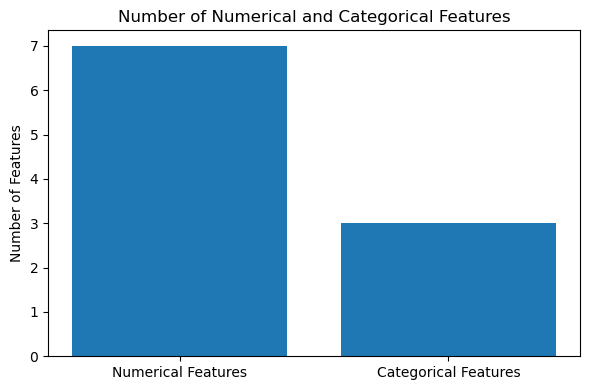

In [23]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt
# Create labels for the chart
feature_type_labels = ["Numerical Features", "Categorical Features"]
# Create values for the chart
feature_type_counts = [num_count, cat_count]
# Create a figure for the chart
plt.figure(figsize=(6, 4))
# Create a bar chart
plt.bar(feature_type_labels, feature_type_counts)
# Add a chart title
plt.title("Number of Numerical and Categorical Features")
# Add a label to the y-axis
plt.ylabel("Number of Features")
# Adjust the layout
plt.tight_layout()
# Display the chart
plt.show()

In [24]:
# creating the x and y columns from the dataset

x = df_clean.drop(columns=[target_column])
# Create y by selecting only the target column
y = df_clean[target_column]
# Print a message to confirm that X and y have been created
print("X and y have been defined successfully.")

print("Shape of X:")
# Display the number of rows and columns in X
print(x.shape)
# Print a separator line
print("-" * 50)
# Print the shape of y
print("Shape of y:")
# Display the number of rows in y
print(y.shape)

X and y have been defined successfully.
Shape of X:
(350, 15)
--------------------------------------------------
Shape of y:
(350,)


In [25]:
# Displaying the first five rows in the dataset

print("First five rows of X:")
# Print a separator line
print("-" * 50)
# Display the first five rows of X
display(x.head())

First five rows of X:
--------------------------------------------------


,Shipment_ID,Order_Date,Customer_Segment,Region,Product_Category,Shipping_Method,Shipping_Distance_km,Package_Weight_kg,Order_Value_CAD,Warehouse_Load_Level,Carrier_Rating,Weather_Risk,Previous_Delivery_Issues,Peak_Season,Promised_Delivery_Days
0,SHP-10001,2026-02-26,Small Business,Ontario,Home Goods,Economy,485,9.8,344.55,High,3.4,Low,0,No,7
1,SHP-10002,2026-04-07,Small Business,British Columbia,Apparel,Express,351,10.5,543.41,Low,4.0,Low,2,No,2
2,SHP-10003,2026-02-23,E-commerce Seller,British Columbia,Office Supplies,Economy,713,11.1,448.06,High,2.5,High,0,No,6
3,SHP-10004,2026-03-10,Enterprise,Ontario,Office Supplies,Express,531,12.2,659.53,Medium,4.0,Medium,2,Yes,1
4,SHP-10005,2026-05-11,E-commerce Seller,Atlantic,Apparel,Express,33,14.8,200.73,Medium,4.2,Medium,0,No,2


In [26]:
print("First five values of y:")
# Print a separator line
print("-" * 50)
# Display the first five values of y
display(y.head())

First five values of y:
--------------------------------------------------


0    0
1    1
2    1
3    1
4    0
Name: Delivery_Delayed, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
# Use X as the input features
x,
# Use y as the target variable
y,
# Use 20% of the data for testing
test_size=0.2,
# Keep the same target class distribution in train and test sets
stratify=y,
# Use a fixed random state to make the result reproducible
random_state=42)

# Print a message to confirm that the data has been split
print("Data has been split into training and testing sets.")

Data has been split into training and testing sets.


In [28]:
print("x_train shape:")
# Display the number of rows and columns in X_train
print(x_train.shape)
# Print a separator line
print("-" * 50)
# Print the shape of X_test
print("X_test shape:")
# Display the number of rows and columns in X_test
print(x_test.shape)
# Print a separator line
print("-" * 50)
# Print the shape of y_train
print("y_train shape:")

print(y_train.shape)
# Print a separator line
print("-" * 50)
# Print the shape of y_test
print("y_test shape:")
# Display the number of target values in y_test
print(y_test.shape)

x_train shape:
(280, 15)
--------------------------------------------------
X_test shape:
(70, 15)
--------------------------------------------------
y_train shape:
(280,)
--------------------------------------------------
y_test shape:
(70,)


In [29]:
print("Target distribution in training set:")
# Print a separator line
print("-" * 50)
# Count the number of Yes and No values in y_train
train_distribution = y_train.value_counts()
# Display the target distribution in the training set
display(train_distribution)

Target distribution in training set:
--------------------------------------------------


Delivery_Delayed
0    198
1     82
Name: count, dtype: int64

In [30]:
print("Target distribution in testing set:")
# Print a separator line
print("-" * 50)
28
# Count the number of Yes and No values in y_test
test_distribution = y_test.value_counts()
# Display the target distribution in the testing set
display(test_distribution)

Target distribution in testing set:
--------------------------------------------------


Delivery_Delayed
0    49
1    21
Name: count, dtype: int64

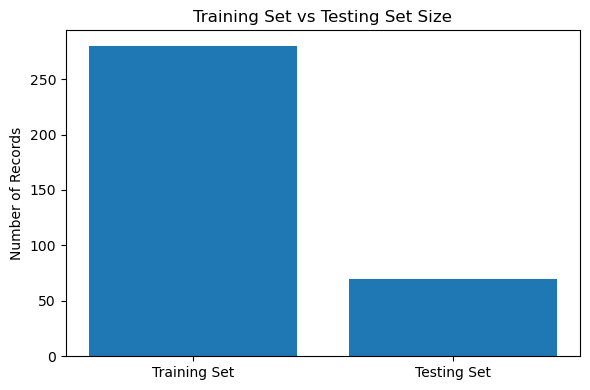

In [31]:
import matplotlib.pyplot as plt
# Create labels for the chart
split_labels = ["Training Set", "Testing Set"]
# Create values for the chart
split_sizes = [len(x_train), len(x_test)]
# Create a figure for the chart
plt.figure(figsize=(6, 4))
# Create a bar chart for train and test size
plt.bar(split_labels, split_sizes)
# Add a title to the chart
plt.title("Training Set vs Testing Set Size")
# Add a label to the y-axis
plt.ylabel("Number of Records")
# Adjust the layout
plt.tight_layout()
# Display the chart
plt.show()

In [35]:
# Preprocessing step

# Import ColumnTransformer to apply different preprocessing steps to different columns. compose import ColumnTransformer
# Import OneHotEncoder to convert categorical variables into numerical columns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Select numerical feature columns from X
numerical_features = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Select categorical feature columns from X
categorical_features = x.select_dtypes(include=["object"]).columns.tolist()
# Print numerical features
print("Numerical features:")
print(numerical_features)
# Print a separator line
print("-" * 50)
# Print categorical features
print("Categorical features:")
print(categorical_features)

Numerical features:
['Shipping_Distance_km', 'Package_Weight_kg', 'Order_Value_CAD', 'Carrier_Rating', 'Previous_Delivery_Issues', 'Promised_Delivery_Days']
--------------------------------------------------
Categorical features:
['Shipment_ID', 'Order_Date', 'Customer_Segment', 'Region', 'Product_Category', 'Shipping_Method', 'Warehouse_Load_Level', 'Weather_Risk', 'Peak_Season']


In [36]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(transformers=[("categorical", encoder, categorical_features),("numerical", "passthrough", numerical_features)])
# Print a message to confirm that the preprocessor has been created
print("Preprocessor has been created successfully.")

Preprocessor has been created successfully.


In [37]:
x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

print("x_test preprocessing completed!")

print("\n")

print("Summary of preprocessing shapes:")  # Print a title for the shape summary

print("x_train before preprocessing:", x_train_preprocessed.shape)  # Print X_train shape before preprocessing

print("x_train after preprocessing:", x_train_preprocessed.shape)  # Print X_train shape after preprocessing

print("x_test before preprocessing:", x_test_preprocessed.shape)  # Print X_test shape before preprocessing

print("x_test after preprocessing:", x_test_preprocessed.shape)  # Print X_test shape after preprocessing


x_test preprocessing completed!


Summary of preprocessing shapes:
x_train before preprocessing: (280, 442)
x_train after preprocessing: (280, 442)
x_test before preprocessing: (70, 442)
x_test after preprocessing: (70, 442)


In [38]:
# Get the new feature names created from categorical variables
encoded_categorical_features = preprocessor.named_transformers_["categorical"].get_feature_names_out(categorical_features)
# Combine encoded categorical feature names with numerical feature names
processed_feature_names = list(encoded_categorical_features) + numerical_features
# Print the total number of processed features
print("Number of processed features:", len(processed_feature_names))
# Print a separator line
print("-" * 50)

# Display the processed feature names
print(processed_feature_names)

Number of processed features: 442
--------------------------------------------------
['Shipment_ID_SHP-10001', 'Shipment_ID_SHP-10004', 'Shipment_ID_SHP-10006', 'Shipment_ID_SHP-10007', 'Shipment_ID_SHP-10008', 'Shipment_ID_SHP-10009', 'Shipment_ID_SHP-10010', 'Shipment_ID_SHP-10011', 'Shipment_ID_SHP-10012', 'Shipment_ID_SHP-10013', 'Shipment_ID_SHP-10014', 'Shipment_ID_SHP-10015', 'Shipment_ID_SHP-10016', 'Shipment_ID_SHP-10017', 'Shipment_ID_SHP-10019', 'Shipment_ID_SHP-10020', 'Shipment_ID_SHP-10021', 'Shipment_ID_SHP-10023', 'Shipment_ID_SHP-10024', 'Shipment_ID_SHP-10025', 'Shipment_ID_SHP-10026', 'Shipment_ID_SHP-10027', 'Shipment_ID_SHP-10028', 'Shipment_ID_SHP-10030', 'Shipment_ID_SHP-10032', 'Shipment_ID_SHP-10033', 'Shipment_ID_SHP-10034', 'Shipment_ID_SHP-10035', 'Shipment_ID_SHP-10036', 'Shipment_ID_SHP-10037', 'Shipment_ID_SHP-10038', 'Shipment_ID_SHP-10039', 'Shipment_ID_SHP-10040', 'Shipment_ID_SHP-10041', 'Shipment_ID_SHP-10044', 'Shipment_ID_SHP-10045', 'Shipment_ID_S

In [39]:
# Convert processed training data into a DataFrame
x_train_processed_df = pd.DataFrame(x_train_preprocessed,columns = processed_feature_names, index = x_train.index)
# Convert processed testing data into a DataFrame
x_test_processed_df = pd.DataFrame(x_test_preprocessed,columns = processed_feature_names, index = x_test.index)
# Display the first five rows of the processed training data
display(x_train_processed_df.head())

,Shipment_ID_SHP-10001,Shipment_ID_SHP-10004,Shipment_ID_SHP-10006,Shipment_ID_SHP-10007,Shipment_ID_SHP-10008,Shipment_ID_SHP-10009,Shipment_ID_SHP-10010,Shipment_ID_SHP-10011,Shipment_ID_SHP-10012,Shipment_ID_SHP-10013,...,Weather_Risk_Low,Weather_Risk_Medium,Peak_Season_No,Peak_Season_Yes,Shipping_Distance_km,Package_Weight_kg,Order_Value_CAD,Carrier_Rating,Previous_Delivery_Issues,Promised_Delivery_Days
149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,681.0,11.2,133.79,4.0,0.0,5.0
159,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,318.0,14.6,86.11,4.3,0.0,2.0
271,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,433.0,9.6,335.77,3.6,1.0,2.0
43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,640.0,7.1,25.00,4.0,0.0,4.0
24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,15.0,9.5,554.91,4.4,1.0,4.0


In [40]:
# Training the decision tree

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
# Limit the depth of the tree to make it easier to understand
max_depth=4,
# Use a fixed random state to make the result reproducible
random_state=42
)
# Print a message to confirm that the model has been created
print("Decision Tree model has been created.")

Decision Tree model has been created.


In [41]:
decision_tree_model.fit(x_train_processed_df,y_train)

print("The decision tree model has trained succesfully")

The decision tree model has trained succesfully


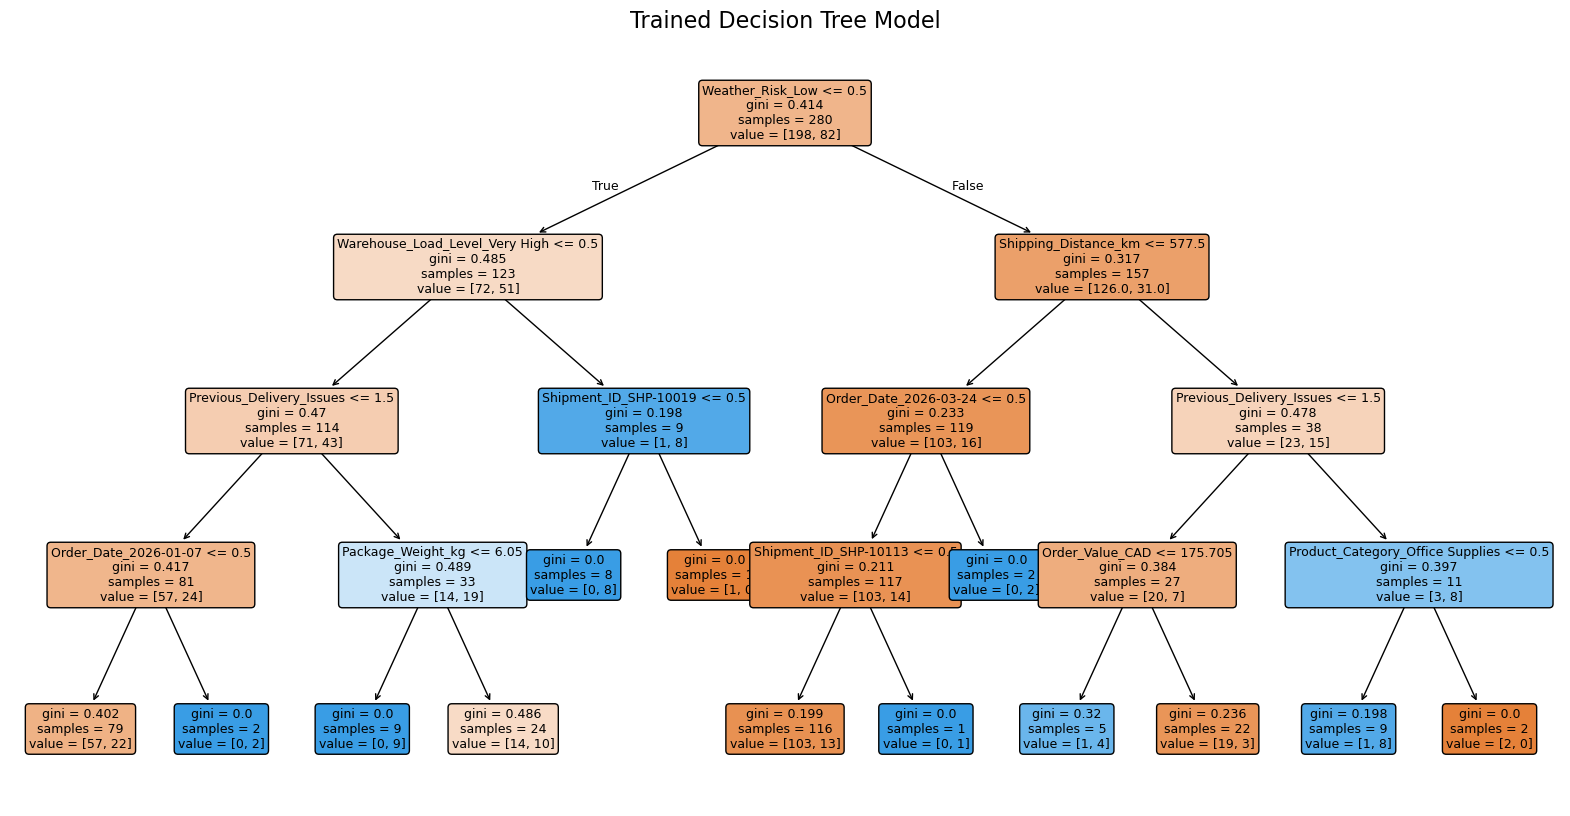

In [43]:
# Using Matplotlib, we are showing the decision tree outcome.

import matplotlib.pyplot as plt
# Import plot_tree to visualize the Decision Tree
from sklearn.tree import plot_tree
# Create a large figure for the tree visualization
plt.figure(figsize=(20, 10))
# Plot the trained Decision Tree
plot_tree(
# Use the trained Decision Tree model
decision_tree_model,
# Use feature names from the processed training data
feature_names = x_train_processed_df.columns,

# Fill the tree boxes to make the classes easier to distinguish
filled= True,
# Round the corners of the boxes
rounded= True,
# Set the font size
fontsize= 9
)
# Add a title to the figure
plt.title("Trained Decision Tree Model", fontsize=16)
# Display the figure
plt.show()

In [44]:
# Get the depth of the trained Decision Tree
tree_depth = decision_tree_model.get_depth()
# Get the number of leaf nodes in the trained Decision Tree
tree_leaves = decision_tree_model.get_n_leaves()
# Print the depth of the tree
print("Decision Tree depth:", tree_depth)
# Print the number of leaf nodes
print("Number of leaf nodes:", tree_leaves)

Decision Tree depth: 4
Number of leaf nodes: 13


In [45]:
y_pred_dt = decision_tree_model.predict(x_test_processed_df)
# Print a message to confirm that predictions have been created
print("Decision Tree predictions have been created successfully.")

Decision Tree predictions have been created successfully.


In [46]:
# Create a DataFrame to compare actual and predicted values
dt_results = pd.DataFrame({
# Store the actual values from the testing set
"Actual": y_test.values,
# Store the predicted values from the Decision Tree model
"Predicted": y_pred_dt
})
# Print a title for the output
print("Actual vs Predicted Values")
# Print a separator line
print("-" * 50)
# Display the first ten actual and predicted values
display(dt_results.head(10))

Actual vs Predicted Values
--------------------------------------------------


,Actual,Predicted
0,1,0
1,0,0
2,1,0
3,0,0
4,1,0
5,1,1
6,0,0
7,0,1
8,1,0
9,0,0


In [47]:
# Now we will check the accuracy of the decision tree fro this dataset

from sklearn.metrics import accuracy_score
# Calculate the accuracy of the Decision Tree model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)
# Print the Decision Tree testing accuracy
print("Decision Tree Test Accuracy:")
# Display the accuracy value
print(dt_test_accuracy)

Decision Tree Test Accuracy:
0.6857142857142857


In [48]:
# Predict the target values for the training data
y_train_pred_dt = decision_tree_model.predict(x_train_processed_df)
# Calculate the accuracy of the model on the training data
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
# Calculate the accuracy of the model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)
# Print the training accuracy
print("Decision Tree Training Accuracy:", dt_train_accuracy)
# Print the testing accuracy
print("Decision Tree Testing Accuracy:", dt_test_accuracy)

Decision Tree Training Accuracy: 0.8214285714285714
Decision Tree Testing Accuracy: 0.6857142857142857


In [50]:
# Confusion matrix in decision tree for more details about the training and testing data

from sklearn.metrics import confusion_matrix
# Import ConfusionMatrixDisplay to visualize the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Import matplotlib for creating the figure
import matplotlib.pyplot as plt 
# Define the class labels in a fixed order

class_labels = [0, 1]
# Calculate the confusion matrix for the Decision Tree model
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=class_labels)
# Print a title for the output
print("Decision Tree Confusion Matrix")
# Print a separator line
print("-" * 50)
# Display the confusion matrix values
print(cm_dt)

Decision Tree Confusion Matrix
--------------------------------------------------
[[43  6]
 [16  5]]


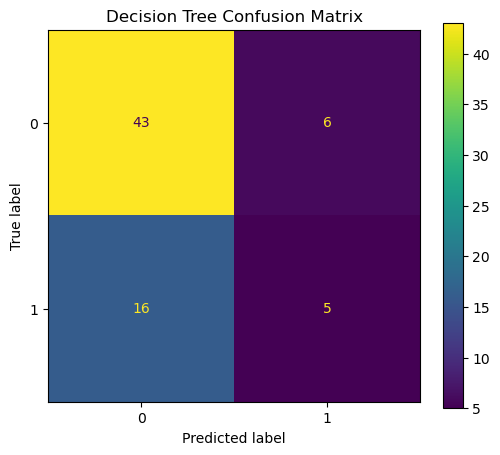

In [51]:
fig, ax = plt.subplots(figsize=(6, 5))
# Create a confusion matrix display object
disp = ConfusionMatrixDisplay(
# Use the Decision Tree confusion matrix
confusion_matrix=cm_dt,
# Use class labels for display
display_labels=class_labels)
# Plot the confusion matrix
disp.plot(ax=ax, values_format="d")
# Add a title to the figure
plt.title("Decision Tree Confusion Matrix")
# Display the figure
plt.show()

In [52]:
# Extract values from the confusion matrix
tn, fp, fn, tp = cm_dt.ravel()
# Print True Negative value
print("True Negative:", tn)
# Print False Positive value
print("False Positive:", fp)
# Print False Negative value
print("False Negative:", fn)
# Print True Positive value
print("True Positive:", tp)

True Negative: 43
False Positive: 6
False Negative: 16
True Positive: 5


In [53]:
# calculating the accuracy,precision, recoll, F1_score, Classification report

# Import accuracy_score to calculate overall correct predictions
from sklearn.metrics import accuracy_score
# Import precision_score to calculate precision
from sklearn.metrics import precision_score
# Import recall_score to calculate recall
from sklearn.metrics import recall_score
# Import f1_score to calculate the F1-score
from sklearn.metrics import f1_score
# Import classification_report to show a full performance summary
from sklearn.metrics import classification_report

In [54]:
# Calculating the accuracy score

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:")
# Display the accuracy value
print(dt_accuracy)

Decision Tree Accuracy:
0.6857142857142857


In [56]:
# Calculating the precision score

dt_precision = precision_score(y_test, y_pred_dt, pos_label = 1,zero_division=0)
# Print the precision score
print("Decision Tree Precision:")
# Display the precision value
print(dt_precision)

Decision Tree Precision:
0.45454545454545453


In [57]:
# Calculating the Recall score 

dt_recall = recall_score(y_test, y_pred_dt, pos_label = 1, zero_division=0)
# Print the recall score
print("Decision Tree Recall:")
# Display the recall value
print(dt_recall)

Decision Tree Recall:
0.23809523809523808


In [58]:
# Calculating the F1 score 

dt_f1 = f1_score(y_test, y_pred_dt, pos_label= 1 , zero_division=0)
# Print the F1-score
print("Decision Tree F1-Score:")
# Display the F1-score value
print(dt_f1)

Decision Tree F1-Score:
0.3125


In [59]:
# Create a DataFrame to summarize the Decision Tree evaluation metrics
dt_metrics_table = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-Score"], "Score": [dt_accuracy, dt_precision, dt_recall, dt_f1]})

# Display the metrics summary table
display(dt_metrics_table)

,Metric,Score
0,Accuracy,0.685714
1,Precision,0.454545
2,Recall,0.238095
3,F1-Score,0.312500


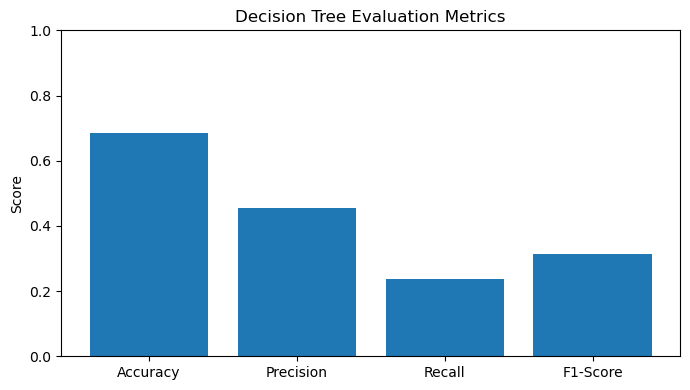

In [60]:
# ploting the above result score using matplotlib for better understanding

import matplotlib.pyplot as plt
# Create a figure for the evaluation metrics chart
plt.figure(figsize=(7, 4))
# Create a bar chart for the metrics
plt.bar(dt_metrics_table["Metric"], dt_metrics_table["Score"])
# Add a title to the chart
plt.title("Decision Tree Evaluation Metrics")
# Add a label to the y-axis
plt.ylabel("Score")
# Set the y-axis range from 0 to 1
plt.ylim(0, 1)
# Adjust the layout so labels do not overlap
plt.tight_layout()
# Display the chart
plt.show()

In [61]:
# Print a title for the classification report
print("Decision Tree Classification Report")
# Print a separator line
print("-" * 50)
# Display the classification report for both classes
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.73      0.88      0.80        49
           1       0.45      0.24      0.31        21

    accuracy                           0.69        70
   macro avg       0.59      0.56      0.55        70
weighted avg       0.65      0.69      0.65        70



In [62]:
# In a Decision Tree, overfitting can happen when the tree becomes too deep and creates too many rules.

# Import DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier
# Create a Decision Tree model without limiting max_depth
overfit_tree_model = DecisionTreeClassifier(
# Allow the tree to grow as much as possible
max_depth=None,
# Use a fixed random state to make the result reproducible
random_state=42)
# Train the overfitted Decision Tree model using the processed training data
overfit_tree_model.fit(x_train_processed_df, y_train)
# Print a message to confirm that the model has been trained
print("Overfitted Decision Tree model has been trained.")

Overfitted Decision Tree model has been trained.


In [63]:
# Predict the target values for the training data using the overfitted tree
y_train_pred_overfit = overfit_tree_model.predict(x_train_processed_df)
# Predict the target values for the testing data using the overfitted tree
y_test_pred_overfit = overfit_tree_model.predict(x_test_processed_df)
# Calculate training accuracy for the overfitted tree
overfit_train_accuracy = accuracy_score(y_train, y_train_pred_overfit)

# Calculate testing accuracy for the overfitted tree
overfit_test_accuracy = accuracy_score(y_test, y_test_pred_overfit)
# Print the training accuracy
print("Overfitted Tree Training Accuracy:", overfit_train_accuracy)
# Print the testing accuracy
print("Overfitted Tree Testing Accuracy:", overfit_test_accuracy)

Overfitted Tree Training Accuracy: 1.0
Overfitted Tree Testing Accuracy: 0.5571428571428572


In [64]:
# Predict the target values for the training data using the controlled Decision Tree
y_train_pred_controlled = decision_tree_model.predict(x_train_processed_df)
# Predict the target values for the testing data using the controlled Decision Tree
y_test_pred_controlled = decision_tree_model.predict(x_test_processed_df)
# Calculate training accuracy for the controlled Decision Tree
controlled_train_accuracy = accuracy_score(y_train, y_train_pred_controlled)
# Calculate testing accuracy for the controlled Decision Tree
controlled_test_accuracy = accuracy_score(y_test, y_test_pred_controlled)
# Create a comparison table for both models
overfitting_comparison = pd.DataFrame({
# Store the model names
"Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
# Store the training accuracy values
"Training Accuracy": [controlled_train_accuracy, overfit_train_accuracy],
# Store the testing accuracy values
"Testing Accuracy": [controlled_test_accuracy, overfit_test_accuracy]})
# Display the comparison table
display(overfitting_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Controlled Decision Tree,0.821429,0.685714
1,Overfitted Decision Tree,1.000000,0.557143


<Figure size 800x500 with 0 Axes>

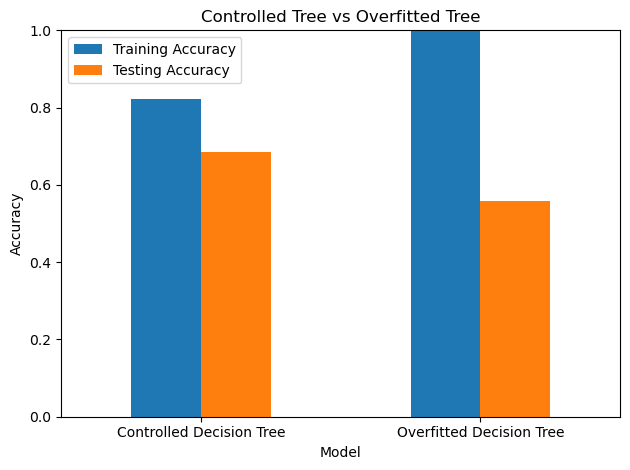

In [65]:
import matplotlib.pyplot as plt
# Set the model column as the index for better plotting
overfitting_comparison_plot = overfitting_comparison.set_index("Model")
# Create a figure for the comparison chart
plt.figure(figsize=(8, 5))
# Create a bar chart for training and testing accuracy
overfitting_comparison_plot.plot(kind="bar")
# Add a title to the chart
plt.title("Controlled Tree vs Overfitted Tree")
# Add a label to the y-axis
plt.ylabel("Accuracy")
# Set the y-axis range from 0 to 1
plt.ylim(0, 1)
# Rotate x-axis labels for better readability
plt.xticks(rotation=0)
# Adjust layout to avoid overlap
plt.tight_layout()
# Display the chart
plt.show()

In [66]:
# Get the depth of the controlled Decision Tree
controlled_tree_depth = decision_tree_model.get_depth()
# Get the number of leaf nodes in the controlled Decision Tree
controlled_tree_leaves = decision_tree_model.get_n_leaves()
# Get the depth of the overfitted Decision Tree
overfit_tree_depth = overfit_tree_model.get_depth()
# Get the number of leaf nodes in the overfitted Decision Tree
overfit_tree_leaves = overfit_tree_model.get_n_leaves()
# Create a table to compare tree complexity
tree_complexity_table = pd.DataFrame({"Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
                                      "Tree Depth": [controlled_tree_depth, overfit_tree_depth],
                                        "Number of Leaves": [controlled_tree_leaves, overfit_tree_leaves]})
# Display the tree complexity table
display(tree_complexity_table)

,Model,Tree Depth,Number of Leaves
0,Controlled Decision Tree,4,13
1,Overfitted Decision Tree,17,54


In [67]:
# To find out the controlled decision tree, we need 
# A very deep tree may memorize the training data instead of learning general patterns.
# To reduce overfitting, we can control the complexity of the Decision Tree using parameters such as:
# max_depth, min_samples_split, min_samples_leaf

controlled_tree_model = DecisionTreeClassifier(
# Limit the maximum depth of the tree
max_depth=4,
# Require at least 5 samples in each leaf node
min_samples_leaf=5,
# Use a fixed random state for reproducible results
random_state=42
)
# Train the controlled Decision Tree model
controlled_tree_model.fit(x_train_processed_df, y_train)
# Print a message to confirm that the controlled model has been trained
print("Controlled Decision Tree model has been trained successfully.")

Controlled Decision Tree model has been trained successfully.


In [68]:
# Predict the target values for the training data
y_train_pred_controlled = controlled_tree_model.predict(x_train_processed_df)

# Predict the target values for the testing data
y_test_pred_controlled = controlled_tree_model.predict(x_test_processed_df)

# Calculate training accuracy for the controlled tree
controlled_train_accuracy = accuracy_score(y_train, y_train_pred_controlled)

# Calculate testing accuracy for the controlled tree
controlled_test_accuracy = accuracy_score(y_test, y_test_pred_controlled)

# Print the training accuracy
print("Controlled Decision Tree Training Accuracy:", controlled_train_accuracy)

# Print the testing accuracy
print("Controlled Decision Tree Testing Accuracy:", controlled_test_accuracy)

Controlled Decision Tree Training Accuracy: 0.8178571428571428
Controlled Decision Tree Testing Accuracy: 0.6571428571428571


In [69]:
# Calculate training accuracy for the original Decision Tree model
original_train_accuracy = accuracy_score(y_train, decision_tree_model.predict(x_train_processed_df))
# Calculate testing accuracy for the original Decision Tree model
original_test_accuracy = accuracy_score(y_test, decision_tree_model.predict(x_test_processed_df))
# Create a comparison table
tree_control_comparison = pd.DataFrame({
# Store model names
"Model": ["Original Decision Tree", "Controlled Decision Tree"],
# Store training accuracy values
"Training Accuracy": [original_train_accuracy, controlled_train_accuracy],
# Store testing accuracy values
"Testing Accuracy": [original_test_accuracy, controlled_test_accuracy]})
# Display the comparison table
display(tree_control_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Original Decision Tree,0.821429,0.685714
1,Controlled Decision Tree,0.817857,0.657143


<Figure size 800x500 with 0 Axes>

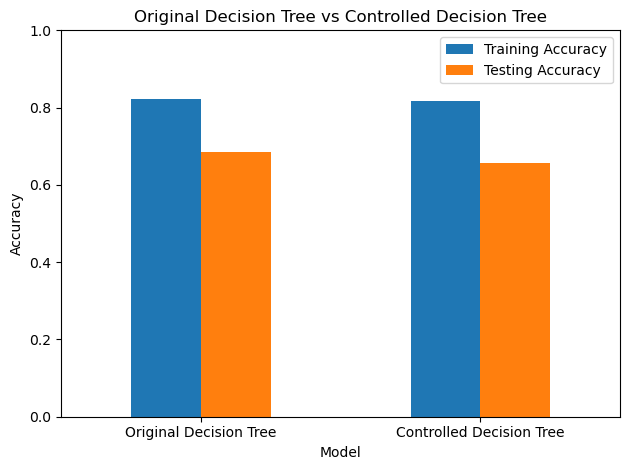

In [70]:
# Set the model column as the index for plotting
tree_control_plot = tree_control_comparison.set_index("Model")

# Create a figure for the comparison chart
plt.figure(figsize=(8, 5))

# Create a bar chart for training and testing accuracy
tree_control_plot.plot(kind="bar")

# Add a title to the chart
plt.title("Original Decision Tree vs Controlled Decision Tree")

# Add a label to the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Rotate x-axis labels to keep them readable
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [72]:
# Get the depth of the original Decision Tree
original_depth = decision_tree_model.get_depth()
# Get the number of leaves in the original Decision Tree
original_leaves = decision_tree_model.get_n_leaves()
# Get the depth of the controlled Decision Tree
controlled_depth = controlled_tree_model.get_depth()
# Get the number of leaves in the controlled Decision Tree
controlled_leaves = controlled_tree_model.get_n_leaves()
# Create a table to compare tree complexity
complexity_comparison = pd.DataFrame({
# Store model names
"Model": ["Original Decision Tree", "Controlled Decision Tree"],
# Store tree depth values
"Tree Depth": [original_depth, controlled_depth],

# Store the number of leaves
    
"Number of Leaves": [original_leaves, controlled_leaves]})
# Display the complexity comparison table
display(complexity_comparison)

,Model,Tree Depth,Number of Leaves
0,Original Decision Tree,4,13
1,Controlled Decision Tree,4,13
